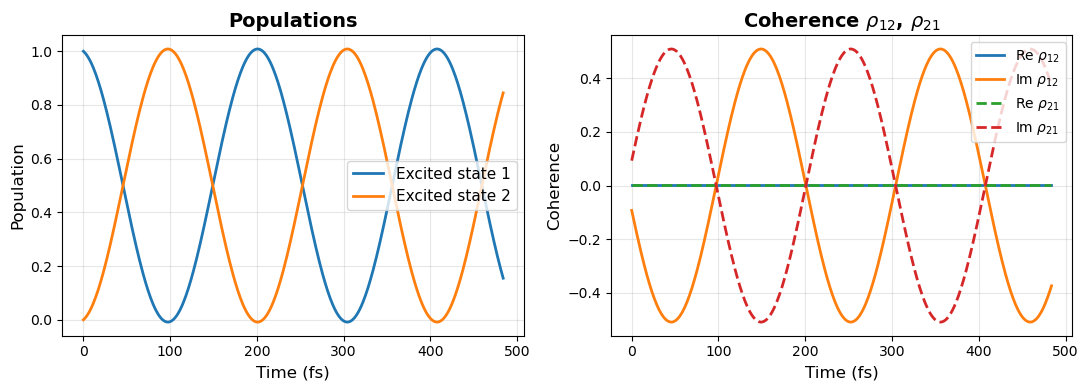

Max populations:
  Excited state 1: 1.0085
  Excited state 2: 1.00849

Total population (should be ~1): 1

Max |rho_12|: 0.508518
Max |rho_21|: 0.508518


In [1]:
#!/usr/bin/env python3
"""
Read and plot population and coherence data from the two-level LVC dynamics.

State ordering from lvc_parameters_mash.py:
- State 0: excited state 1
- State 1: excited state 2

Coherences from rho.npz (written with -rho):
- rho_12 = rho[0, 1]
- rho_21 = rho[1, 0]
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_states_expected = 2

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_states_expected:
    raise ValueError(f"Expected {n_states_expected} states, found {n_states}")

rho = np.load("rho.npz")
rho_re = rho["rho_re"]
rho_im = rho["rho_im"]
time_rho = rho["time"] * autos * 1e15  # au to fs

if rho_re.shape[1:] != (n_states_expected, n_states_expected):
    raise ValueError(f"Expected rho shape (*, {n_states_expected}, {n_states_expected}), got {rho_re.shape}")

# Excited states 1,2 <-> indices 0,1
rho12 = rho_re[:, 0, 1] + 1j * rho_im[:, 0, 1]
rho21 = rho_re[:, 1, 0] + 1j * rho_im[:, 1, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for state in range(n_states_expected):
    ax.plot(time, populations[:, state], label=f"Excited state {state + 1}", linewidth=2)
ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Population", fontsize=12)
ax.set_title("Populations", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(time_rho, rho12.real, label=r"Re $\rho_{12}$", linewidth=2)
ax.plot(time_rho, rho12.imag, label=r"Im $\rho_{12}$", linewidth=2)
ax.plot(time_rho, rho21.real, "--", label=r"Re $\rho_{21}$", linewidth=2)
ax.plot(time_rho, rho21.imag, "--", label=r"Im $\rho_{21}$", linewidth=2)
ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Coherence", fontsize=12)
ax.set_title(r"Coherence $\rho_{12}$, $\rho_{21}$", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for state in range(n_states_expected):
    print(f"  Excited state {state + 1}: {populations[:, state].max():.6g}")
print(f"\nTotal population (should be ~1): {populations.sum(axis=1).mean():.6g}")
print(f"\nMax |rho_12|: {np.abs(rho12).max():.6g}")
print(f"Max |rho_21|: {np.abs(rho21).max():.6g}")


In [2]:
# Quick checks: population conservation and hermiticity of rho_12 / rho_21
print("Total population mean:", populations.sum(axis=1).mean())
print("max |Re(rho_12) - Re(rho_21)|:", np.max(np.abs(rho12.real - rho21.real)))
print("max |Im(rho_12) + Im(rho_21)|:", np.max(np.abs(rho12.imag + rho21.imag)))


Total population mean: 0.9999999999996426
max |Re(rho_12) - Re(rho_21)|: 0.0
max |Im(rho_12) + Im(rho_21)|: 0.0
